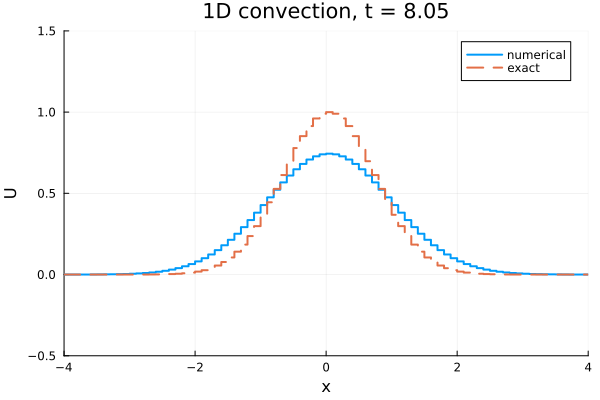

In [2]:
using Plots

# ---------------------------------------
# 1D linear convection, finite volume
# periodic boundary conditions
# ---------------------------------------

# Set up grid
xL = -4.0
xR =  4.0
Nx = 80                         # number of control volumes
x = collect(range(xL, xR, length = Nx + 1))

# Midpoints of each control volume
xmid = 0.5 .* (x[1:Nx] .+ x[2:Nx+1])

# Uniform cell size
dx = x[2] - x[1]

# Velocity
u = 1.0

# Final time
tfinal = 8.0

# Time step from CFL
CFL = 0.5
dt = CFL * dx / abs(u)

# Initial condition
U = exp.(-xmid.^2)
t = 0.0

# Domain length for periodic wrapping
L = xR - xL

# Use a notebook-friendly backend if needed
# gr()

while t < tfinal

    # Periodic ghost-cell extension
    Ubc = vcat(U[end], U, U[1])

    # Numerical flux at interfaces
    F = 0.5 * u .* (Ubc[2:Nx+2] .+ Ubc[1:Nx+1]) .-
        0.5 * abs(u) .* (Ubc[2:Nx+2] .- Ubc[1:Nx+1])

    # Residual in each cell
    R = F[2:Nx+1] .- F[1:Nx]

    # Forward Euler update
    U = U .- (dt / dx) .* R

    # Increment time
    t += dt

    # Exact solution: shifted and wrapped Gaussian
    xshift = xmid .- u * t
    xwrap = xL .+ mod.(xshift .- xL, L)
    Uexact = exp.(-xwrap.^2)

    # Build plot
    p = plot(
        x, [U; U[end]],
        seriestype = :steppost,
        linewidth = 2,
        label = "numerical",
        xlabel = "x",
        ylabel = "U",
        title = "1D convection, t = $(round(t, digits=2))",
        xlims = (xL, xR),
        ylims = (-0.5, 1.5),
        grid = true,
        legend = :topright
    )

    plot!(
        p,
        x, [Uexact; Uexact[end]],
        seriestype = :steppost,
        linewidth = 2,
        linestyle = :dash,
        label = "exact"
    )

    IJulia.clear_output(true)
    display(p)
    sleep(0.05)
    
end

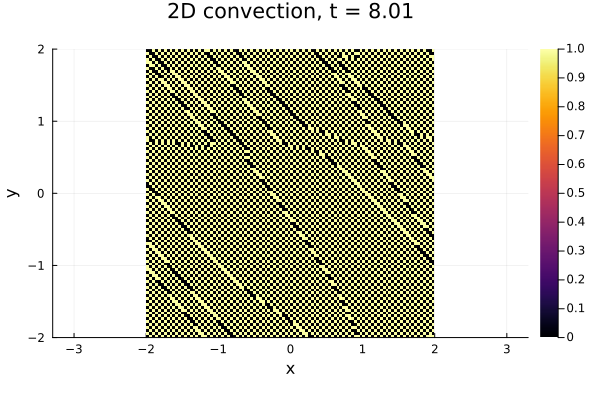

In [3]:
using Plots
using IJulia

# ---------------------------------------
# 2D linear convection, finite volume
# periodic boundary conditions
# constant velocity on a rectangular mesh
# ---------------------------------------

# Specify x range and number of cells
x0 = -2.0
x1 =  2.0
Nx = 100

# Specify y range and number of cells
y0 = -2.0
y1 =  2.0
Ny = 100

# Construct mesh edges
x = collect(range(x0, x1, length = Nx + 1))
y = collect(range(y0, y1, length = Ny + 1))

# Midpoints of control volumes
xmid = 0.5 .* (x[1:Nx] .+ x[2:Nx+1])
ymid = 0.5 .* (y[1:Ny] .+ y[2:Ny+1])

# Build midpoint grid
# ndgrid-style layout: first index = x, second index = y
xmidg = repeat(xmid, 1, Ny)
ymidg = repeat(ymid', Nx, 1)

# Cell sizes and area
dx = x[2] - x[1]
dy = y[2] - y[1]
A  = dx * dy

# Velocity
u = 1.0
v = 1.0

# Final time
tfinal = 8.0

# Time step
CFL = 1.1
dt = CFL / (abs(u)/dx + abs(v)/dy)

# Initial condition
U = exp.(-xmidg.^2 .- 20.0 .* ymidg.^2)
t = 0.0

# Plot only every few steps for smoother notebook behavior
plot_every = 2
step = 0

while t < tfinal
    step += 1

    # Create array with one layer of ghost cells
    Ubc = zeros(Nx + 2, Ny + 2)

    # Copy interior
    Ubc[2:Nx+1, 2:Ny+1] .= U

    # Periodic boundaries on left/right
    Ubc[1,    2:Ny+1] .= U[end, :]
    Ubc[Nx+2, 2:Ny+1] .= U[1,   :]

    # Periodic boundaries on bottom/top
    Ubc[2:Nx+1, 1]    .= U[:, end]
    Ubc[2:Nx+1, Ny+2] .= U[:, 1]

    # Corner ghost cells
    Ubc[1,    1]    = U[end, end]
    Ubc[1,    Ny+2] = U[end, 1]
    Ubc[Nx+2, 1]    = U[1, end]
    Ubc[Nx+2, Ny+2] = U[1, 1]

    # Fluxes across i-interfaces
    F = 0.5 * u .* (Ubc[2:Nx+2, 2:Ny+1] .+ Ubc[1:Nx+1, 2:Ny+1]) .-
        0.5 * abs(u) .* (Ubc[2:Nx+2, 2:Ny+1] .- Ubc[1:Nx+1, 2:Ny+1])

    # Fluxes across j-interfaces
    G = 0.5 * v .* (Ubc[2:Nx+1, 2:Ny+2] .+ Ubc[2:Nx+1, 1:Ny+1]) .-
        0.5 * abs(v) .* (Ubc[2:Nx+1, 2:Ny+2] .- Ubc[2:Nx+1, 1:Ny+1])

    # Residual
    R = (F[2:Nx+1, :] .- F[1:Nx, :]) .* dy .+
        (G[:, 2:Ny+1] .- G[:, 1:Ny]) .* dx

    # Forward Euler update
    U .-= (dt / A) .* R

    # Increment time
    t += dt

    # Plot periodically
    if step % plot_every == 0 || t >= tfinal
        IJulia.clear_output(true)

        p = heatmap(
            xmid, ymid, U',
            aspect_ratio = :equal,
            clims = (0.0, 1.0),
            xlabel = "x",
            ylabel = "y",
            title = "2D convection, t = $(round(t, digits=2))",
            colorbar = true
        )
        
        display(p)
        sleep(0.05)
    end
end

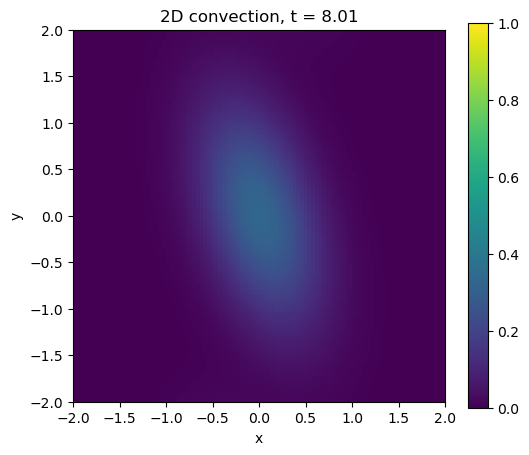

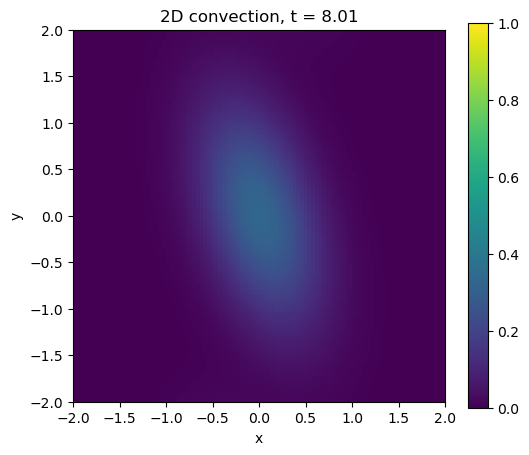

In [3]:
using PyPlot
using IJulia

# Specify x range and number of cells
x0 = -2.0
x1 =  2.0
Nx = 100

# Specify y range and number of cells
y0 = -2.0
y1 =  2.0
Ny = 100

# Construct mesh edges
x = collect(range(x0, x1, length = Nx + 1))
y = collect(range(y0, y1, length = Ny + 1))

# Midpoints
xmid = 0.5 .* (x[1:Nx] .+ x[2:Nx+1])
ymid = 0.5 .* (y[1:Ny] .+ y[2:Ny+1])

# ndgrid-style arrays
xmidg = repeat(xmid, 1, Ny)
ymidg = repeat(ymid', Nx, 1)

# Cell sizes and area
dx = x[2] - x[1]
dy = y[2] - y[1]
A  = dx * dy

# Velocity
u = 1.0
v = 1.0

# Final time and timestep
tfinal = 8.0
CFL = 0.9
dt = CFL / (abs(u)/dx + abs(v)/dy)

# Initial condition
U = exp.(-xmidg.^2 .- 20.0 .* ymidg.^2)
t = 0.0

plot_every = 2
step = 0

pygui(false)

fig, ax = subplots(figsize=(6, 5))

pcm = ax.pcolormesh(x, y, U', shading="flat", vmin=0.0, vmax=1.0)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
cb = fig.colorbar(pcm, ax=ax)

display(fig)

while t < tfinal
    step += 1

    Ubc = zeros(Nx + 2, Ny + 2)
    Ubc[2:Nx+1, 2:Ny+1] .= U

    Ubc[1,    2:Ny+1] .= U[end, :]
    Ubc[Nx+2, 2:Ny+1] .= U[1,   :]
    Ubc[2:Nx+1, 1]    .= U[:, end]
    Ubc[2:Nx+1, Ny+2] .= U[:, 1]

    Ubc[1,    1]    = U[end, end]
    Ubc[1,    Ny+2] = U[end, 1]
    Ubc[Nx+2, 1]    = U[1, end]
    Ubc[Nx+2, Ny+2] = U[1, 1]

    F = 0.5 * u .* (Ubc[2:Nx+2, 2:Ny+1] .+ Ubc[1:Nx+1, 2:Ny+1]) .-
        0.5 * abs(u) .* (Ubc[2:Nx+2, 2:Ny+1] .- Ubc[1:Nx+1, 2:Ny+1])

    G = 0.5 * v .* (Ubc[2:Nx+1, 2:Ny+2] .+ Ubc[2:Nx+1, 1:Ny+1]) .-
        0.5 * abs(v) .* (Ubc[2:Nx+1, 2:Ny+2] .- Ubc[2:Nx+1, 1:Ny+1])

    R = (F[2:Nx+1, :] .- F[1:Nx, :]) .* dy .+
        (G[:, 2:Ny+1] .- G[:, 1:Ny]) .* dx

    U .-= (dt / A) .* R
    t += dt

    if step % plot_every == 0 || t >= tfinal
        # Update the cell colors in-place
        pcm.set_array(vec(U'))

        ax.set_title("2D convection, t = $(round(t, digits=2))")

        IJulia.clear_output(true)
        display(fig)
        sleep(0.05)
    end
end